# Manual Features from Satellite Imagery

This notebook derives per-LSOA spectral features from a Landsat 8 surface-reflectance scene (2019-08-26, London extent).

## Data

We work with two inputs: a multi-band NetCDF raster derived from Landsat 8 and the London LSOA polygon boundaries (2020 definition) used throughout the workshop.

In [1]:
%matplotlib inline
import numpy as np
import pandas
import geopandas
import xarray as xr
import regionmask
import matplotlib.pyplot as plt

ERROR 1: PROJ: proj_create_from_database: Open of /opt/conda/envs/gds/share/proj failed


### Satellite imagery

`london_landsat.nc` contains surface reflectance for bands B1–B7 of Landsat 8, reprojected to EPSG:4326. We use the `scipy` engine because the standard `netCDF4` C extension is not available in the WASM kernel.

In [2]:
sr = xr.open_dataset('london_landsat.nc', engine='scipy')['SR']
sr

<xarray.DataArray 'SR' (band: 7, y: 1141, x: 2314)> Size: 148MB
[18481918 values with dtype=float64]
Coordinates:
  * band     (band) object 56B 'B1' 'B2' 'B3' 'B4' 'B5' 'B6' 'B7'
  * y        (y) float64 9kB 51.7 51.7 51.7 51.7 ... 51.28 51.28 51.28 51.27
  * x        (x) float64 19kB -0.5196 -0.5192 -0.5189 ... 0.3434 0.3438 0.3441
Attributes:
    AREA_OR_POINT:  Area

### LSOA boundaries

We reuse the geometry column from the embeddings GeoJSON, which already carries the 2020 LSOA definitions for London.

In [3]:
lsoa = geopandas.read_file('uk_lsoa_london_embeds_2020.geojson')[['LSOA21CD', 'geometry']]

## True color view

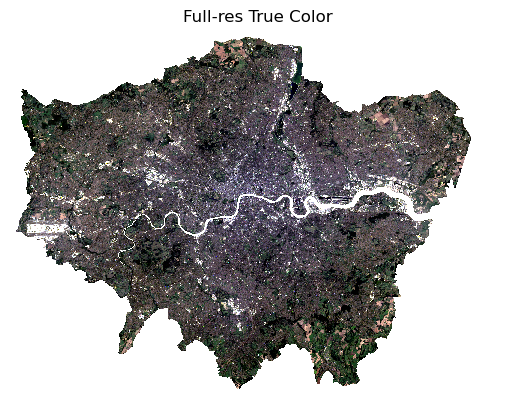

In [4]:
rgb = sr.sel(band=['B4', 'B3', 'B2'])    # <1>
lo = rgb.quantile(0.02, dim=['x', 'y'])  # <2>
hi = rgb.quantile(0.98, dim=['x', 'y'])  # <2>
ax = (
    ((rgb - lo) / (hi - lo))             # <3>
    .clip(0, 1)                          # <4>
    .plot.imshow()                       # <5>
)
ax.axes.set_axis_off()                   # <6>
ax.axes.set_title('Full-res True Color');# <6>
plt.show()                               # <7>

1. Extract red, green, blue bands
2. Identify the 2nd and 98th percentile values
3. Normalise to [0, 1]
4. Clip outliers
5. Display
6. Style the map
7. Explicitly render image

## Zonal statistics

We want one row per LSOA with the mean surface reflectance for each of the 7 bands — a 7-feature vector per area.

Computing this at full resolution (~30 m pixels, 1504 × 1943 grid) is memory-intensive in the browser. We use two approaches:

- **Demo (below):** coarsen the raster 8× before masking — fast enough to run live, slightly less precise
- **Pre-computed (below):** load `landsat_features.csv`, computed offline at full resolution and bundled with the workshop

### Coarsened zonal statistics

Coarsening by 8× reduces the grid from 1504 × 1943 to ~188 × 243 pixels (~240 m resolution), which is still well within LSOA size (~500 m across) and runs in seconds in the browser.

In [5]:
sr_coarse = sr.coarsen(x=10, y=10, boundary='trim').mean()

Display coarsened:

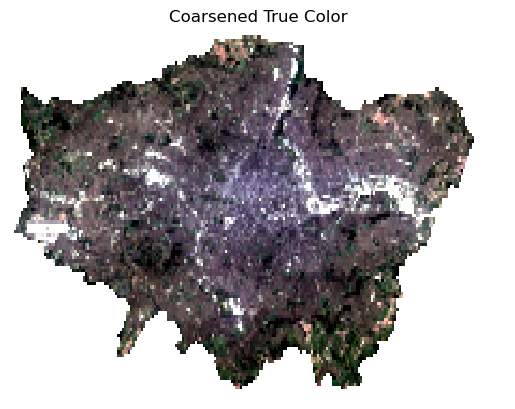

In [6]:
rgb_c = sr_coarse.sel(band=['B4', 'B3', 'B2'])
lo_c = rgb_c.quantile(0.02, dim=['x', 'y'])  
hi_c = rgb_c.quantile(0.98, dim=['x', 'y'])  
ax = (
    ((rgb_c - lo_c) / (hi_c - lo_c))             
    .clip(0, 1)                          
    .plot.imshow()                       
)
ax.axes.set_axis_off()                   
ax.axes.set_title('Coarsened True Color')
plt.show()

Create a mask from the polygons:

In [7]:
mask = regionmask.mask_geopandas(
    lsoa.reset_index(), lon_or_obj=sr_coarse.x, lat=sr_coarse.y, numbers='index'
)

Obtain mean values for each band by grouping by polygon and store as a `DataFrame`:

In [8]:
lookup = xr.DataArray(lsoa['LSOA21CD'], dims='mask')
lsoa_bands = sr_coarse.groupby(mask).mean()
coarse_features = (
    lsoa_bands
    .transpose('mask', 'band')
    .assign_coords(LSOA21CD=lookup.sel(mask=lsoa_bands['mask']))
    .swap_dims({'mask': 'LSOA21CD'})
    .to_pandas()
    .rename(columns=lambda c: f"{c.replace('B', 'band_')}_mean")
)

### Full-resolution features (pre-computed)

`landsat_features.csv` was computed offline at full ~30m resolution[^1].

[^1]: You can see the full process [here](../../data_prep/lab_00-Data_prep.ipynb).

In [9]:
hires_features = pandas.read_csv('landsat_features.csv', index_col='LSOA21CD')

We can compare the pattern for each band across both resolutions to explore potential loss of information with the coarsening:

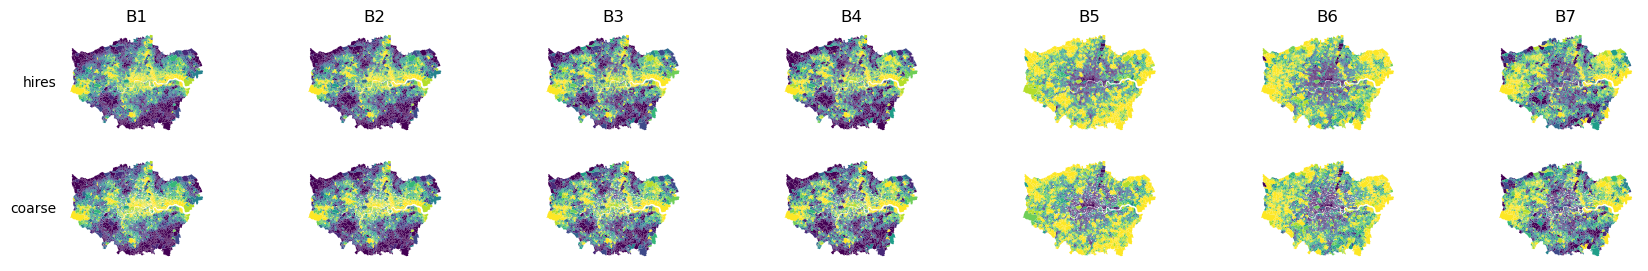

In [10]:
f, axs = plt.subplots(2, len(lsoa_bands["band"]), figsize=(21, 3))

for i, (label, version) in enumerate(zip(["hires", "coarse"], [hires_features, coarse_features])):
    for j, band in enumerate(lsoa_bands["band"]):
        ax = axs[i, j]
        col = f"{str(band.data).replace("B", "band_")}_mean"
        (
            lsoa
            .join(version, on="LSOA21CD")
            .plot(column=col, scheme="quantiles", k=10, ax=ax)
        )
        ax.set_axis_off()
        if i == 0:
            ax.set_title(str(band.data))
        if j == 0:
            ax.text(-0.05, 0.5, label, transform=ax.transAxes, ha="right", va="center")
plt.show()